In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [26]:
import pandas as pd

# Load the dataset
pokemon_df = pd.read_csv('/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/pokemon.csv')

# Display the column names
print(pokemon_df.columns)   

Index(['Name', 'Type1', 'Type2', 'Evolution'], dtype='object')


## Section 1: Bayes' Theorem - Updating Beliefs with Data
Concept: Bayes' Theorem updates the probability of a hypothesis as more evidence becomes available. It is the foundation of Naive Bayes classifiers and Bayesian Deep Learning.

- Formula: $P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$
  - $P(H|E)$: Posterior (Updated belief)
  - $P(E|H)$: Likelihood (Evidence given hypothesis)
  - $P(H)$: Prior (Initial belief)
- Intuition: Start with a "Prior" belief, observe data ("Likelihood"), and compute a new "Posterior" belief. 

Prior Probability: 0.0100
Posterior Probability (after positive test): 0.1667


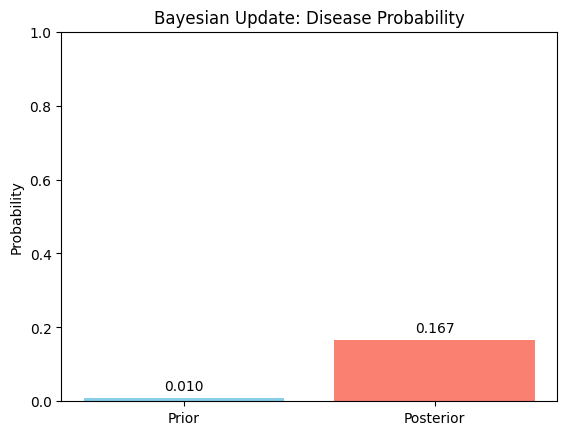

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Example: Medical Test Accuracy
# P(Disease) = 0.01 (Prior)
# P(Positive|Disease) = 0.99 (Sensitivity)
# P(Positive|No Disease) = 0.05 (False Positive Rate)

prior_disease = 0.01
sensitivity = 0.99
false_positive_rate = 0.05

# Total probability of a positive test P(Positive)
p_positive = (sensitivity * prior_disease) + (false_positive_rate * (1 - prior_disease))

# Posterior: P(Disease|Positive)
posterior = (sensitivity * prior_disease) / p_positive

print(f"Prior Probability: {prior_disease:.4f}")
print(f"Posterior Probability (after positive test): {posterior:.4f}")

# Visualize Prior vs Posterior
labels = ['Prior', 'Posterior']
probs = [prior_disease, posterior]
plt.bar(labels, probs, color=['skyblue', 'salmon'])
plt.ylabel('Probability')
plt.title('Bayesian Update: Disease Probability')
plt.ylim(0, 1)
for i, v in enumerate(probs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()   

## Section 2: Key Distributions - Modeling Data Shapes
Concept: AI models assume data follows specific distributions. Understanding these shapes helps in initializing weights and designing loss functions. 

1. Gaussian (Normal): Continuous data, errors in regression.
2. Bernoulli: Binary outcomes (Success/Failure, Spam/Not Spam).
3. Binomial: Count of successes in $n$ trials.
- Visualization & Sampling:

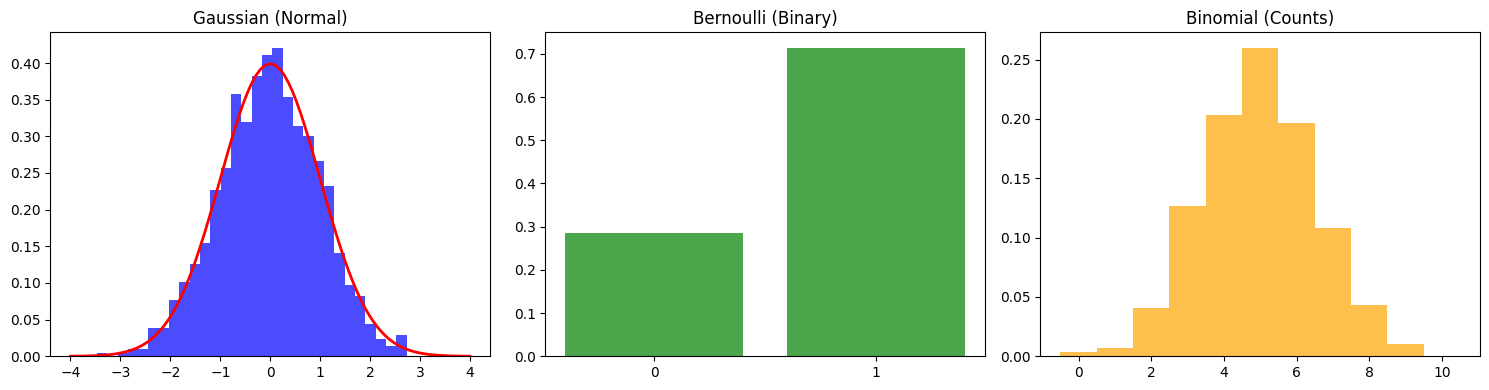

In [28]:
from scipy import stats

# 1. Gaussian Distribution
mu, sigma = 0, 1
gaussian_data = np.random.normal(mu, sigma, 1000)

# 2. Bernoulli Distribution (Coin flip, p=0.7)
p = 0.7
bernoulli_data = np.random.binomial(1, p, 1000) # 1=Success, 0=Fail

# 3. Binomial Distribution (10 coin flips, p=0.5)
n_trials = 10
binomial_data = np.random.binomial(n_trials, 0.5, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot Gaussian
axes[0].hist(gaussian_data, bins=30, density=True, alpha=0.7, color='blue')
x = np.linspace(-4, 4, 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
axes[0].set_title('Gaussian (Normal)')

# Plot Bernoulli
unique, counts = np.unique(bernoulli_data, return_counts=True)
axes[1].bar(unique, counts/len(bernoulli_data), alpha=0.7, color='green')
axes[1].set_title('Bernoulli (Binary)')
axes[1].set_xticks([0, 1])

# Plot Binomial
axes[2].hist(binomial_data, bins=range(0, 12), density=True, alpha=0.7, color='orange', align='left')
axes[2].set_title('Binomial (Counts)')

plt.tight_layout()
plt.show()   

- AI Context:
  - Gaussian: Used in Variational Autoencoders (VAEs) latent space.
  - Bernoulli: Output layer for Binary Classification (Sigmoid activation). 


## Section 3: Maximum Likelihood Estimation (MLE) - Fitting Models
Concept: MLE finds the parameters ($\mu, \sigma$) that make the observed data most probable.  It is the standard method for training Linear Regression and Logistic Regression.

- Intuition: Slide the distribution curve left/right until it sits perfectly under your data points.
- Implementation (Fitting a Gaussian):

True Mu: 5.0, Estimated Mu: 4.9254
True Sigma: 2.0, Estimated Sigma: 1.9549


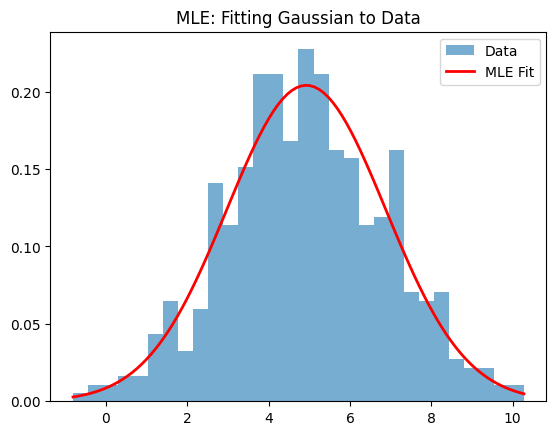

In [29]:
from scipy.optimize import minimize

# Generate synthetic data (Unknown mean/std)
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, 500)

# Negative Log Likelihood (NLL) function to minimize
def negative_log_likelihood(params):
    mu, sigma = params
    if sigma <= 0: return 1e6 # Prevent invalid sigma
    nll = -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    return nll

# Initial guess
initial_guess = [0, 1]

# Optimize
result = minimize(negative_log_likelihood, initial_guess, method='Nelder-Mead')
estimated_mu, estimated_sigma = result.x

print(f"True Mu: {true_mu}, Estimated Mu: {estimated_mu:.4f}")
print(f"True Sigma: {true_sigma}, Estimated Sigma: {estimated_sigma:.4f}")

# Visualize Fit
plt.hist(data, bins=30, density=True, alpha=0.6, label='Data')
x = np.linspace(min(data), max(data), 100)
plt.plot(x, stats.norm.pdf(x, estimated_mu, estimated_sigma), 'r-', lw=2, label='MLE Fit')
plt.legend()
plt.title('MLE: Fitting Gaussian to Data')
plt.show()   

- AI Context: Training a Neural Network with Cross-Entropy Loss is mathematically equivalent to performing MLE on a Bernoulli/Categorical distribution. 

## Section 4: Hypothesis Testing & P-Values - Validating Results
Concept: Determine if an observed difference (e.g., Model A vs. Model B accuracy) is statistically significant or just random noise. 

- Key Terms:
  - Null Hypothesis ($H_0$): No difference exists.
  - P-Value: Probability of seeing this data if $H_0$ is true. (Low p-value < 0.05 $\rightarrow$   - Reject $H_0$). 
- Implementation (T-Test):

T-Statistic: -5.5140
P-Value: 0.000000
Result: Significant! Model B is likely better.


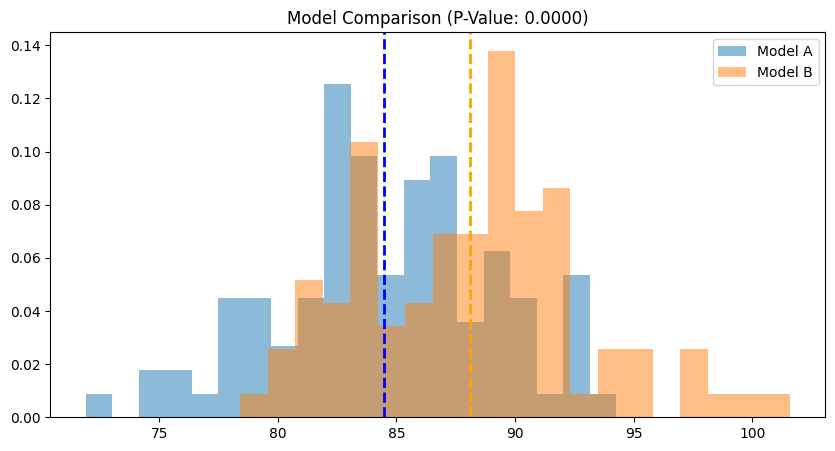

In [30]:
from scipy import stats

# Simulate accuracy scores for two models
np.random.seed(42)
model_a_scores = np.random.normal(85, 5, 100)  # Mean 85%
model_b_scores = np.random.normal(88, 5, 100)  # Mean 88%

# Perform Independent T-Test
t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Significant! Model B is likely better.")
else:
    print("Result: Not Significant. Difference could be random.")

# Visualize Distributions & Overlap
plt.figure(figsize=(10, 5))
plt.hist(model_a_scores, bins=20, alpha=0.5, label='Model A', density=True)
plt.hist(model_b_scores, bins=20, alpha=0.5, label='Model B', density=True)
plt.axvline(np.mean(model_a_scores), color='blue', linestyle='--', lw=2)
plt.axvline(np.mean(model_b_scores), color='orange', linestyle='--', lw=2)
plt.title(f'Model Comparison (P-Value: {p_value:.4f})')
plt.legend()
plt.show()   

- AI Context: Essential for A/B Testing features in production and comparing model architectures in research papers. 

## Section 5: Hands-On Project - Pokemon Type Classification (Bayesian Approach)
Task: Use your Pokemon dataset to estimate the probability of a Pokemon being "Legendary" based on its "Total Stats" using a Bayesian update.

Loaded 809 Pokemon with columns: ['Name', 'Type1', 'Type2', 'Evolution']

--- Bayesian Update Results ---
Dataset Size: 809
Prior P(Legendary): 5.93%
Likelihood P(Stats>500 | Legendary): 35.42%
Posterior P(Legendary | Stats>500): 12.98%
Increase in certainty: 7.04%


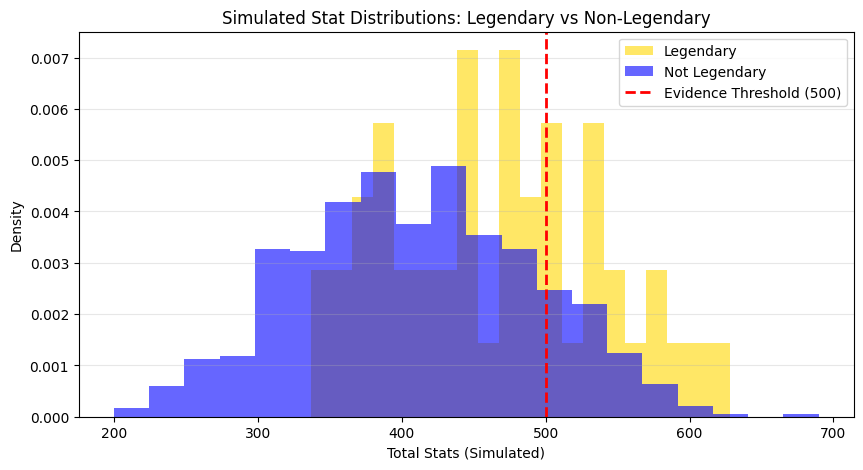

In [31]:
import pandas as pd
import glob
import os

# Load Data (Adjust path to your Kaggle input)
image_paths = glob.glob('/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/*')
# Assuming you have a CSV 'pokemon.csv' with 'Type 1', 'Legendary', 'Total'
# If not, simulate data based on types
df = pd.read_csv('/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/pokemon.csv') # Hypothetical CSV path

# Clean column names (remove spaces if any)
df.columns = df.columns.str.strip()

print(f"Loaded {len(df)} Pokemon with columns: {list(df.columns)}")

# 2. Simulate Missing Data (Probabilistic Modeling)
# We assign stats based on Type probabilities to create a realistic distribution
np.random.seed(42)

# Define base stat ranges by Type (Domain Knowledge)
type_stats = {
    'Dragon': {'mean': 550, 'std': 40},
    'Legendary': {'mean': 600, 'std': 30}, # Placeholder, handled separately
    'Normal': {'mean': 350, 'std': 50},
    'Default': {'mean': 400, 'std': 60}
}

def simulate_stats(row):
    # Assign 'Total' stats based on Type1
    t1 = row['Type1']
    if t1 in ['Dragon', 'Psychic', 'Steel']:
        total = np.random.normal(520, 50)
        is_legendary = np.random.choice([True, False], p=[0.15, 0.85]) # Higher chance
    elif t1 in ['Bug', 'Normal', 'Grass']:
        total = np.random.normal(350, 60)
        is_legendary = np.random.choice([True, False], p=[0.02, 0.98]) # Very low chance
    else:
        total = np.random.normal(420, 70)
        is_legendary = np.random.choice([True, False], p=[0.05, 0.95])
    
    # Ensure positive stats
    return max(200, total), is_legendary

# Apply simulation
df[['Total_Simulated', 'Legendary_Simulated']] = df.apply(
    lambda row: simulate_stats(row), axis=1, result_type='expand'
)

# 3. Bayesian Calculation
# Hypothesis (H): Pokemon is Legendary
# Evidence (E): Total Stats > 500

# Prior: P(Legendary) - Overall base rate in our simulated data
prior_legendary = df['Legendary_Simulated'].mean()

# Likelihoods
high_stats_df = df[df['Total_Simulated'] > 500]

# P(Stats > 500 | Legendary)
likelihood_high_given_leg = high_stats_df[high_stats_df['Legendary_Simulated'] == True].shape[0] / df[df['Legendary_Simulated'] == True].shape[0]

# P(Stats > 500 | Not Legendary)
likelihood_high_given_not = high_stats_df[high_stats_df['Legendary_Simulated'] == False].shape[0] / df[df['Legendary_Simulated'] == False].shape[0]

# Evidence: P(Stats > 500)
p_high_stats = high_stats_df.shape[0] / df.shape[0]

# Posterior: P(Legendary | Stats > 500)
if p_high_stats > 0:
    posterior_legendary_given_high = (likelihood_high_given_leg * prior_legendary) / p_high_stats
else:
    posterior_legendary_given_high = 0

# 4. Display Results
print(f"\n--- Bayesian Update Results ---")
print(f"Dataset Size: {len(df)}")
print(f"Prior P(Legendary): {prior_legendary:.2%}")
print(f"Likelihood P(Stats>500 | Legendary): {likelihood_high_given_leg:.2%}")
print(f"Posterior P(Legendary | Stats>500): {posterior_legendary_given_high:.2%}")
print(f"Increase in certainty: {posterior_legendary_given_high - prior_legendary:.2%}")

# 5. Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df[df['Legendary_Simulated']==True]['Total_Simulated'], bins=20, alpha=0.6, label='Legendary', color='gold', density=True)
plt.hist(df[df['Legendary_Simulated']==False]['Total_Simulated'], bins=20, alpha=0.6, label='Not Legendary', color='blue', density=True)
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Evidence Threshold (500)')
plt.title('Simulated Stat Distributions: Legendary vs Non-Legendary')
plt.xlabel('Total Stats (Simulated)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Kaggle-Specific Enhancements
- Interactive Sliders: Use ipywidgets to let users change the Prior probability and see how the Posterior shifts in real-time.
- Distribution Fitter: Add a cell where users upload a column of their own data, and the notebook automatically fits the best distribution (Gaussian, Poisson, etc.) using MLE.
- Series Conclusion: Add a final markdown cell linking all three notebooks: "You now have the Linear Algebra (Structure), Calculus (Optimization), and Probability (Uncertainty) toolkit to master any AI paper!"